In [1]:
import numpy as np
import json
import math
import os

def load_contingency_matrix(results_dir):

    with open(results_dir, 'r') as f:
        data = json.load(f)
    
    input_dataset_path = os.path.join('..', data['input_dataset'])
    results = data['results']
    
    with open(input_dataset_path, 'r') as f:
        input_dataset = json.load(f)
    
    top_k = input_dataset['top_k']
    samples_per_query = input_dataset['samples_per_query']
    if samples_per_query == 0:
        samples_per_query = math.factorial(top_k)
    
    # This is required by the statistical test
    assert input_dataset['share_permutations']
    
    skipped_samples = list()
    skipped_queries = set()
    for i,result_sample in enumerate(results):
        pred_pos = result_sample['predicted_pos']
        if pred_pos is None or not isinstance(pred_pos, int) or pred_pos < 1 or pred_pos > top_k:
            skipped_queries.add(i // samples_per_query)
            skipped_samples.append(i)
    
    
    skip_samples = True
    skip_queries = False
    cm = np.zeros((top_k, samples_per_query))
    unshuffled_cm = np.zeros((top_k, samples_per_query))
    
    for i,(result_sample,query_info) in enumerate(zip(results, input_dataset['queries'])):
        query_id = i//samples_per_query
        permutation_id = i%samples_per_query
    
        if skip_samples and i in skipped_samples:
            continue
        if skip_queries and query_id in skipped_queries:
            continue
    
        pred_pos = result_sample['predicted_pos'] - 1
        true_pred_pos = query_info['permutation'][pred_pos]
        unshuffled_cm[true_pred_pos,permutation_id] += 1
        cm[pred_pos,permutation_id] += 1

    return cm, unshuffled_cm, input_dataset, samples_per_query, top_k

In [2]:
contingency_values_as_true_positions = False

experiment_name = 'position_bias__share'
filename = 'evaluation_llama8b.json'
results_dir = os.path.join('..', 'results', experiment_name, filename)

cm, unshuffled_cm, input_dataset, samples_per_query, top_k = load_contingency_matrix(results_dir)

In [3]:
from scipy.stats import chi2_contingency

shuffles_subsample_size = 120
num_queries = len(input_dataset['queries']) // samples_per_query

# Generate a subsample
shuffles_subsample_indices = np.arange(samples_per_query)
np.random.shuffle(shuffles_subsample_indices)
shuffles_subsample_indices = shuffles_subsample_indices[:shuffles_subsample_size]

contingency_matrix_test = cm.copy()
contingency_matrix_test = contingency_matrix_test[:,shuffles_subsample_indices]

# Run chi-squared test for independence
chi2_stat, p_value, dof, expected = chi2_contingency(contingency_matrix_test, correction=False)

# Output results
print(f"Chi-squared statistic: {chi2_stat:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"P-value: {p_value:.4e}")

if p_value < 0.05:
    print("Reject the null hypothesis: distributions differ across permutations.")
else:
    print("Fail to reject the null hypothesis: no evidence that y affects the distribution.")

cramers_v = np.sqrt(chi2_stat / (np.sum(contingency_matrix_test) * (min(contingency_matrix_test.shape) - 1)))
print("Cramér’s V:", cramers_v)

np.sum(cm)

Chi-squared statistic: 1645.7744
Degrees of freedom: 476
P-value: 1.7113e-128
Reject the null hypothesis: distributions differ across permutations.
Cramér’s V: 0.0686842363484091


87216.0

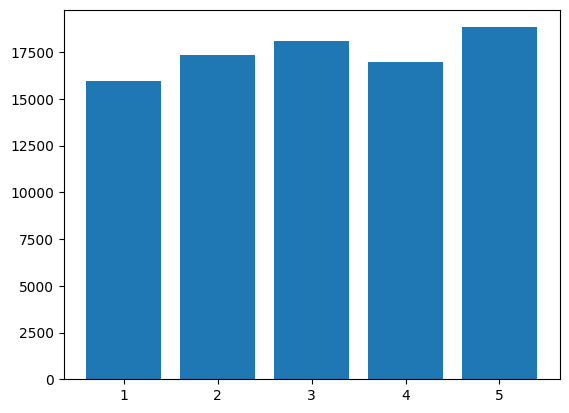

array([15949., 17364., 18094., 16975., 18834.])

In [4]:
import matplotlib.pyplot as plt

plt.bar(range(1, top_k+1), np.sum(cm, axis=1))
plt.savefig(f"../figures/raw_probability_distribution.pdf", format="pdf", bbox_inches="tight")
plt.show()

np.sum(cm, axis=1)

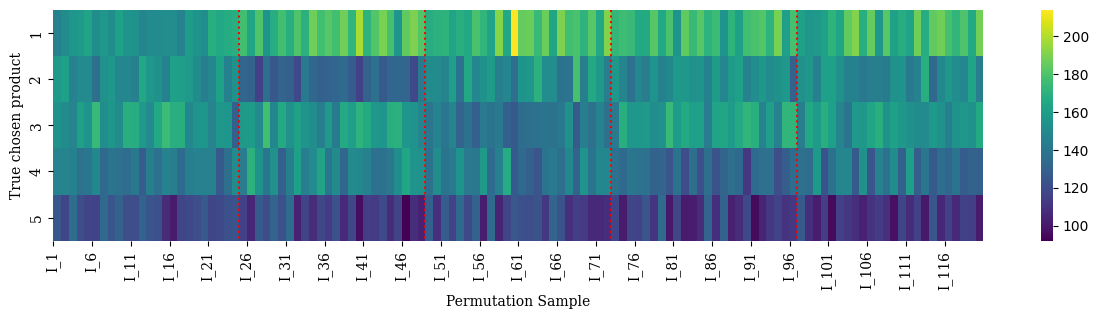

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

swap_axes = False

fig, ax = plt.subplots(figsize=(8, 10) if swap_axes else (15, 3))
sns.heatmap(unshuffled_cm.T if swap_axes else unshuffled_cm, cmap="viridis", ax=ax)

for i in range(1, top_k):
    ax.plot([0, top_k] if swap_axes else [24*i, 24*i], [24*i, 24*i] if swap_axes else [0, top_k], linestyle = 'dotted', color='red')

step = 5
tick_locs = list(range(0, samples_per_query, step))
tick_labels = [f"I_{s+1}" for s in tick_locs]

set_xticklabels = ax.set_yticklabels if swap_axes else ax.set_xticklabels
set_xticks = ax.set_yticks if swap_axes else ax.set_xticks
set_yticklabels = ax.set_xticklabels if swap_axes else ax.set_yticklabels
set_yticks = ax.set_xticks if swap_axes else ax.set_yticks
set_xlabel = ax.set_ylabel if swap_axes else ax.set_xlabel
set_ylabel = ax.set_xlabel if swap_axes else ax.set_ylabel

font_config = {'fontname':'Serif'}

set_yticklabels(range(1, top_k+1), **font_config)
set_xticks(tick_locs)
set_xticklabels(tick_labels, **font_config)

set_ylabel("True chosen product", **font_config)
set_xlabel("Permutation Sample", **font_config)
# ax.set_title("True chosen product Distribution per Permutation", **font_config)

plt.savefig(f"../figures/all_distribution_probabilities__{'vertical' if swap_axes else 'horizontal'}.pdf", format="pdf", bbox_inches="tight")

plt.show()

In [6]:
def compute_blocks(product_pos, top_k, samples_per_query, input_dataset):
    blocks = []
    for block_pos in range(top_k):
        blocks.append([])
        for i in range(samples_per_query):
            permutation = input_dataset['queries'][i]['permutation']
            if permutation[product_pos] == block_pos:
                blocks[-1].append(i)
    return blocks

[]

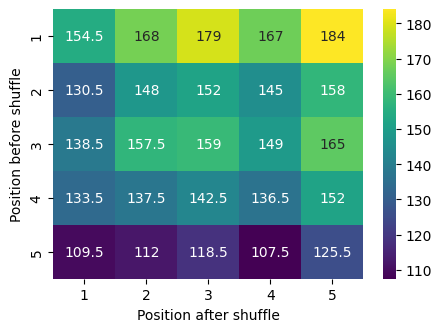

In [7]:
import seaborn as sns

def plot_bias_interpretability(unshuffled_cm, input_dataset, top_k, ax, plot_nums, show_x_axis=True, show_y_axis=True, ranges=None, show_colorbar=True):

    # Input: array of shape (top_k, samples_per_query)
    #  - Each column represents the probability distribution (non-normalized) of selecting 
    #    the ith-product (i is the row)
    # contingency_matrix
    
    # Output: array of shape (top_k, top_k)
    #  - Each row represents the medians of counts of selected products that were on position i (row) and
    #    was moved to position j (column)
    matrix_counts = np.zeros((top_k, top_k))
    
    
    for orig_pos in range(top_k):
    
        test_set = set()
    
        for target_pos in range(top_k):
    
            # Array of shape (top_k, samples_per_query//top_k)
            #  - Each ith-row (block) represents a set of indices of shuffles, 
            #    where these shuffles moves products from position i to target_pos
            blocks = np.array(compute_blocks(target_pos, top_k, samples_per_query, input_dataset))
    
            # List of counts (each one is like a sample), where the selected product was at orig_pos, 
            # was moved to the target_pos and it was selected by the model
            counts = unshuffled_cm[orig_pos, blocks[orig_pos]]
            test_set.update(blocks[orig_pos])
            
            # Compute the mean for a robust representation
            median = np.median(counts)
    
            matrix_counts[orig_pos, target_pos] = median
    
        assert len(test_set) == samples_per_query

    vmin = ranges[0] if ranges is not None else None
    vmax = ranges[1] if ranges is not None else None
    sns.heatmap(matrix_counts, vmin=vmin, vmax=vmax, cmap="viridis", ax=ax, annot=plot_nums, fmt='g', cbar=show_colorbar)

    if show_x_axis:
        ax.set_xticklabels(range(1, top_k+1))
        ax.set_xlabel('Position after shuffle')
    else:
        ax.set_xticklabels([])

    if show_y_axis:
        ax.set_ylabel('Position before shuffle')
        ax.set_yticklabels(range(1, top_k+1))
    else:
        ax.set_yticklabels([])

    ax.tick_params(left=show_y_axis, bottom=show_x_axis)

    return matrix_counts


fig, ax = plt.subplots(figsize=(5, 3.5))
plot_bias_interpretability(unshuffled_cm, input_dataset, top_k, ax, plot_nums=True)

plt.savefig(f"../figures/bias_analysis.pdf", format="pdf", bbox_inches="tight")

plt.plot()

In [8]:
87600 - np.sum(cm)

384.0

In [9]:
from tqdm.auto import tqdm

models = [
    'DeepSeek R1 32B (Qwen distill)',
    'DeepSeek R1 7B (Qwen distill)',
    'DeepSeek R1 8B (LLaMA distill)',
    'LLaMA 3.1 8B',
    'LLaMA 4 Scout',
    'GPT OSS 120B',
    'GPT-OSS 20B',
    'LLaMA 3.1 70B',
]

filenames = {
    'DeepSeek R1 32B (Qwen distill)': 'evaluation_deepseek-r1_32b-qwen-distill-fp16.json',
    'DeepSeek R1 7B (Qwen distill)': 'evaluation_deepseek-r1_7b-qwen-distill-fp16.json',
    'DeepSeek R1 8B (LLaMA distill)': 'evaluation_deepseek-r1_8b-llama-distill-fp16.json',
    'GPT OSS 120B': 'evaluation_gpt-oss_120b.json',
    'GPT-OSS 20B': 'evaluation_gpt_oss_20b.json',
    'LLaMA 3.1 70B': 'evaluation_llama3.1_70b-instruct-fp16.json',
    'LLaMA 3.1 8B': 'evaluation_llama8b.json',
    'LLaMA 4 Scout': 'evaluation_llama4_scout.json'
}

cm_set = dict()

for model_name in tqdm(models):

    results_dir = os.path.join('..', 'results', experiment_name, filenames[model_name])
    cm, unshuffled_cm, input_dataset, samples_per_query, top_k = load_contingency_matrix(results_dir)

    cm_set[model_name] = {
        'cm': cm,
        'unshuffled_cm': unshuffled_cm,
        'input_dataset': input_dataset,
        'samples_per_query': samples_per_query,
        'top_k': top_k
    }

  0%|          | 0/8 [00:00<?, ?it/s]

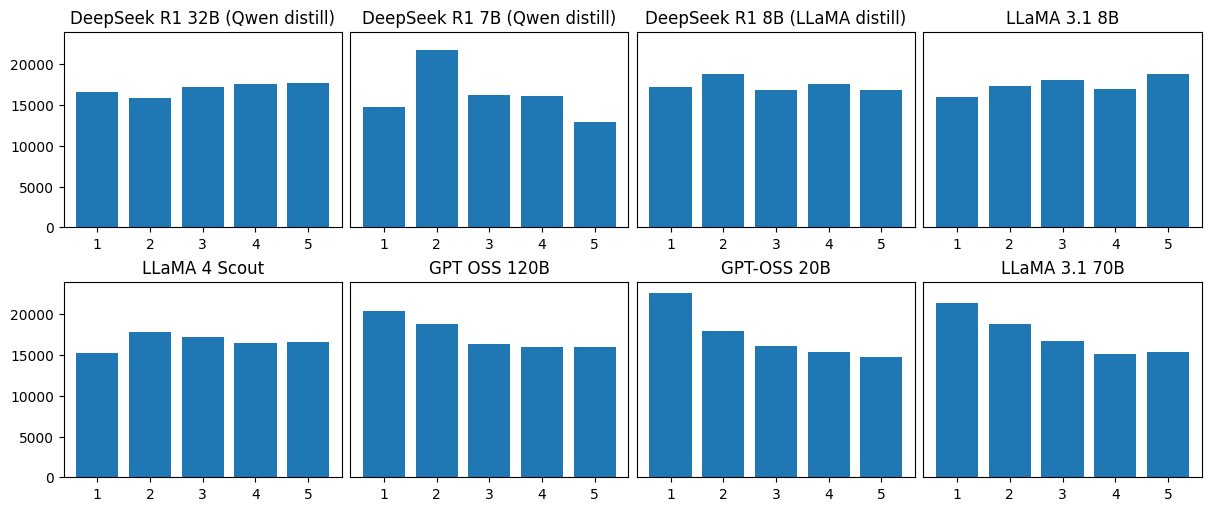

In [12]:
ncols = 4
nrows = len(models) // ncols
if len(models)%ncols != 0:
    nrows += 1

fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 5), constrained_layout = True)

for i,model_name in enumerate(models):
    x_ticks = range(1, cm_set[model_name]['top_k']+1)
    axs[i//ncols][i%ncols].bar(x_ticks, np.sum(cm_set[model_name]['cm'], axis=1))
    axs[i//ncols][i%ncols].set_ylim(0, 24000)
    axs[i//ncols][i%ncols].set_xticks(range(1, cm_set[model_name]['top_k']+1))
    if i%ncols != 0:
        axs[i//ncols][i%ncols].get_yaxis().set_visible(False)
    axs[i//ncols][i%ncols].title.set_text(model_name)
if len(models)%ncols != 0:
    fig.delaxes(axs[nrows-1][len(models)%ncols])
plt.savefig(f"../figures/all_raw_probability_distributions.pdf", format="pdf", bbox_inches="tight")
plt.show()

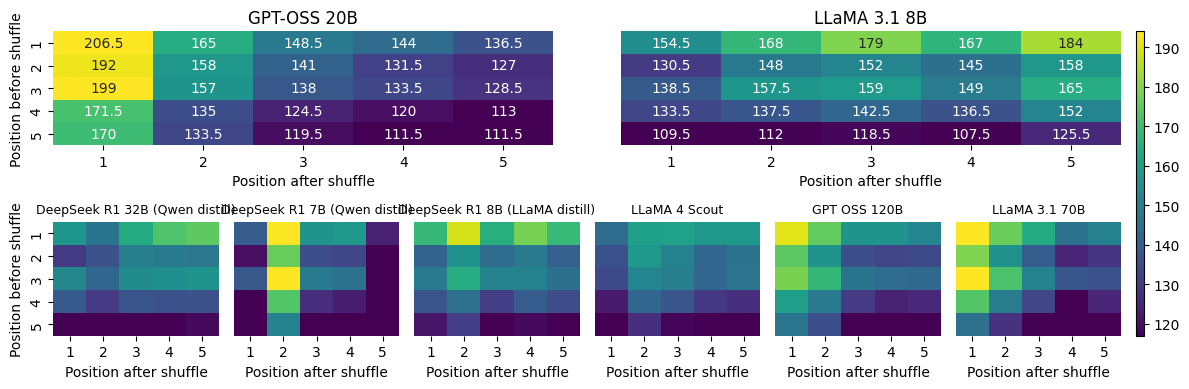

In [11]:
import matplotlib.gridspec as gridspec

highlighted_models = ['GPT-OSS 20B', 'LLaMA 3.1 8B']
other_models = [model for model in models if model not in highlighted_models]

fig = plt.figure(figsize=(12, 4))
gs = gridspec.GridSpec(2, len(highlighted_models)*len(other_models)+1, 
                       figure=fig, width_ratios=[1]*(len(highlighted_models)*len(other_models)) + [0.1])

# Compute ranges (add an offset to highlight less biased models)
vmin = min([np.min(data['unshuffled_cm']) for data in cm_set.values()])+40
vmax = max([np.max(data['unshuffled_cm']) for data in cm_set.values()])-40

# Row 1 (highlighted models)
highlighted_axs = []
for i,model in enumerate(highlighted_models):
    grid_min = i*len(other_models)
    grid_max = (i+1)*len(other_models)
    ax = fig.add_subplot(gs[0, grid_min:grid_max])
    plot_bias_interpretability(
        cm_set[model]['unshuffled_cm'], 
        cm_set[model]['input_dataset'], 
        cm_set[model]['top_k'], 
        ax, 
        plot_nums=True,
        ranges=(vmin,vmax),
        show_y_axis=(i==0),
        show_colorbar=False
    )
    ax.title.set_text(model)
    highlighted_axs.append(ax)

# Row 2 (rest of models)
for i,model in enumerate(other_models):
    # plot_bias_interpretability(plot_nums, show_x_axis=True, show_y_axis=True, ranges=None, show_colorbar=True)
    ax = fig.add_subplot(gs[1, (i*len(highlighted_models)):((i+1)*len(highlighted_models))])
    plot_bias_interpretability(
        cm_set[model]['unshuffled_cm'], 
        cm_set[model]['input_dataset'], 
        cm_set[model]['top_k'], 
        ax, 
        plot_nums=False,
        ranges=(vmin,vmax),
        show_y_axis=(i==0),
        show_colorbar=False
    )
    ax.title.set_text(model)
    ax.title.set_fontsize(9)

# Colorbar
cax = fig.add_subplot(gs[0:2, -1])
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
sm.set_array([])  # dummy mappable
fig.colorbar(sm, cax=cax)

plt.tight_layout()

# Add margin to first row
margin = 0.05
for i,ax in enumerate(highlighted_axs):
    pos = ax.get_position()
    if i == 0:
        x_offset = 0
    elif i == len(highlighted_axs)-1:
        x_offset = margin/2.3
    else:
        x_offset = margin/2.3
    ax.set_position([pos.x0+x_offset, pos.y0, pos.width*(1-margin), pos.height])

plt.savefig(f"../figures/all_bias_analysis.pdf", format="pdf", bbox_inches="tight")
plt.show()